In [15]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
%matplotlib inline


# Ambrosio - Tortorelli Approximation

In [22]:
# Parameters

grid = np.arange(-1, 1.01, 0.01)
delta_x = 0.01
eps = 0.05
b = 5
a = 1


In [23]:
# Set-up

def weighted_sum(u, alpha):
    weights = (1 - (alpha[:-1] + alpha [1:])/2) ** 2
    diffs = u[1:] - u[:-1]   
    return 1/2 * (cp.sum(cp.multiply(weights, cp.square(diffs))) / delta_x)

def Argmin_u_update(alpha, g_mid):
    u = cp.Variable(201)
    objective = cp.Minimize(weighted_sum(u, alpha) + delta_x * b * cp.sum_squares((u[:-1]+u[1:])/2 - g_mid))
    prob = cp.Problem(objective)
    prob.solve()
    return u.value

def Argmin_alpha_update(u, beta, w, rho):
    alpha = cp.Variable(201)
    objective = cp.Minimize(weighted_sum(u, alpha) + rho/2 * cp.sum_squares(alpha - beta + w))
    constraints = [alpha[0] == 0, alpha >= 0, alpha <= 1]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return alpha.value

def Argmin_beta_update(alpha, w, rho):
    beta = cp.Variable(201)
    objective = cp.Minimize(a/2 * (delta_x / (4 * eps) * cp.sum_squares(beta[:-1] + beta[1:]) + eps / delta_x * cp.sum_squares(beta[1:] - beta[:-1])) + rho/2 * cp.sum_squares(alpha - beta + w))
    constraints = [beta[0] == 0, beta >= 0, beta <= 1]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return beta.value


In [24]:
# Define g

g = grid * 6
g_mid = (g[:-1]+ g[1:]) / 2 # midpoints of g for integration

In [25]:
# ADMM

alpha = np.zeros(201)
beta = np.zeros(201)
w = np.zeros(201)

alpha_all = alpha
beta_all = beta

rho = 5

E_admm = []

r_norm = []
s_norm = []

r_tol = 10e-4
s_tol = 10e-4

r_new = 10e5
s_new = 10e5

num_iter = 0

while (r_tol < r_new or s_tol < s_new) and num_iter < 1000:
    beta_old = beta.copy()
    u = Argmin_u_update(alpha, g_mid) # u - update
    alpha = Argmin_alpha_update(u, beta, w, rho) # alpha  - update
    alpha_all = np.vstack([alpha_all, alpha])
    beta = Argmin_beta_update(alpha, w, rho) # beta - update
    beta_all = np.vstack([beta_all, beta])
    w = w + alpha - beta # dual variable update (scaled form)

    r = alpha - beta # primal residual
    r_new = np.linalg.norm(r)
    r_norm.append(r_new)

    s = rho * (beta - beta_old) # dual redisual
    s_new = np.linalg.norm(s)
    s_norm.append(s_new)

    E_val = (1/2 * (np.sum((1 - (alpha[:-1] + alpha[1:])/2)**2 
                    * (u[1:] - u[:-1])**2) / delta_x)
        + delta_x * b * np.sum(((u[:-1] + u[1:])/2 - g_mid)**2)
        + a/2 * (delta_x / (4 * eps) * np.sum((beta[:-1] + beta[1:])**2)
                  + eps / delta_x * np.sum((beta[1:] - beta[:-1])**2)))

    E_admm.append(E_val)

    num_iter +=1

r_norm = np.array(r_norm)
s_norm = np.array(s_norm)
alpha_optimal = alpha

print(f"{num_iter} iterations")

u_admm = u
alpha_admm = alpha

255 iterations


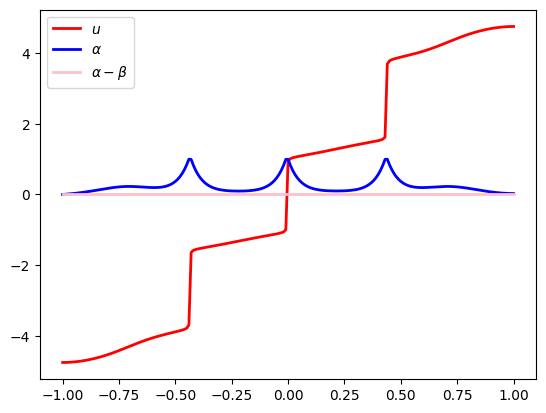

In [26]:
# Plotting u, alpha and beta

plt.close('all')
fig, ax = plt.subplots()
ax.plot(grid, u, linewidth = 2, color = 'red', label = r'$u$')
ax.plot(grid, alpha, linewidth = 2, color = 'blue', label = r'$\alpha$')
ax.plot(grid, alpha - beta, linewidth = 2, color = 'pink', label = r'$\alpha - \beta$')
ax.legend()



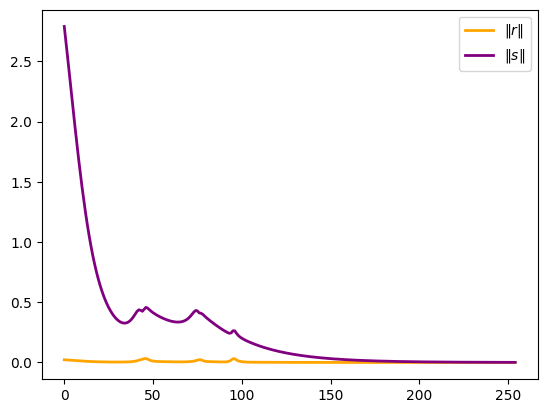

In [27]:
#Plotting primal and dual residuals

plt.close('all')
fig, ax = plt.subplots()
ax.plot(r_norm, linewidth = 2, color = 'orange', label = r'$\|r\|$')
ax.plot(s_norm, linewidth = 2, color = 'purple', label = r'$\|s\|$')
ax.legend()

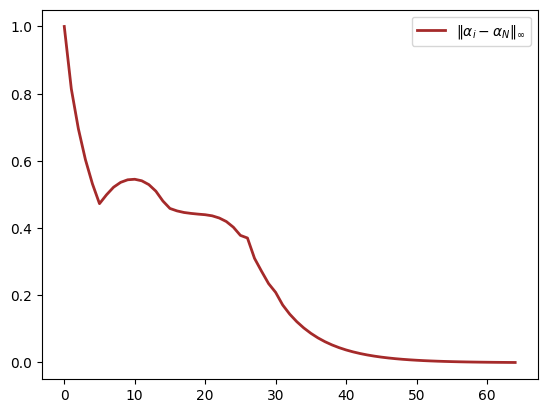

In [675]:
# Plotting \|alpha_i - alpha_N\|_\infty as a function of i where N = num_iter

alpha_diff = alpha_all - alpha_optimal
alpha_diff_norm = np.zeros(len(alpha_diff))

for i in range(len(alpha_diff)) :
    alpha_diff_norm[i] = np.linalg.norm(alpha_diff[i], np.inf)

plt.close('all')
fig, ax = plt.subplots()
ax.plot(alpha_diff_norm, linewidth = 2, color = 'brown', label = r'$\|\alpha_i - \alpha_N\|_\infty$')
ax.legend()



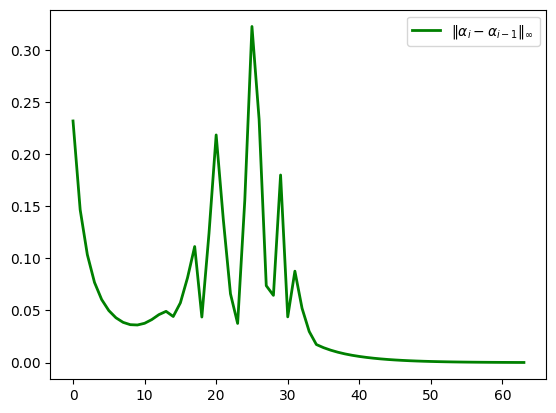

In [676]:
# Plotting \|alpha_i - alpha_{i-1}\|_\infty as a function of i

alpha_change = alpha_all[1:, :] - alpha_all[:-1, :]
alpha_change_norm = np.zeros(len(alpha_change))

for i in range(len(alpha_change)):
    alpha_change_norm[i] = np.linalg.norm(alpha_change[i], np.inf)

plt.close('all')
fig, ax = plt.subplots()
ax.plot(alpha_change_norm, linewidth = 2, color = 'green', label = r'$\|\alpha_i - \alpha_{i-1} \|_\infty$')
ax.legend()

In [ ]:
# Parameter Adjusment for Alternating Minimization (if needed)

eps = 0.05
b = 5
a = 2

g = np.where(grid >=0, 1, -1)
g = grid * 3
g_mid = (g[:-1]+ g[1:]) / 2 # midpoints of g for integration


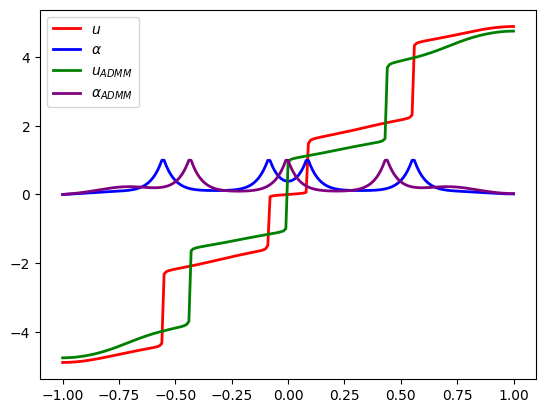

In [28]:

# Alternating Minimization

alpha = np.zeros(201)

def Argmin_alpha_update_AM(u):
    alpha = cp.Variable(201)
    objective = cp.Minimize(weighted_sum(u, alpha) + delta_x * b * cp.sum_squares((u[:-1]+u[1:])/2 - g_mid) 
                            + a/2 * (delta_x / (4 * eps) * cp.sum_squares(alpha[:-1] + alpha[1:]) + eps / delta_x * cp.sum_squares(alpha[1:] - alpha[:-1])))
    constraints = [alpha[0] == 0, alpha >= 0, alpha <= 1]
    prob = cp. Problem(objective, constraints)
    prob.solve()
    return alpha.value


E_am = []

for _ in range(num_iter):
    u = Argmin_u_update(alpha, g_mid)
    alpha = Argmin_alpha_update_AM(u)
    E_val = (1/2 * (np.sum((1 - (alpha[:-1] + alpha[1:])/2)**2 
                        * (u[1:] - u[:-1])**2) / delta_x)
         + delta_x * b * np.sum(((u[:-1] + u[1:])/2 - g_mid)**2)
         + a/2 * (delta_x / (4 * eps) * np.sum((alpha[:-1] + alpha[1:])**2)
                  + eps / delta_x * np.sum((alpha[1:] - alpha[:-1])**2)))

    E_am.append(E_val)

    
plt.close('all')
fig, ax = plt.subplots()
ax.plot(grid, u, linewidth = 2, color = 'red', label = r'$u$')
ax.plot(grid, alpha , linewidth = 2, color = 'blue', label = r'$\alpha$')
ax.plot(grid, u_admm, linewidth = 2, color = 'green', label = r'$u_{ADMM}$')
ax.plot(grid, alpha_admm, linewidth = 2, color = 'purple', label = r'$\alpha_{ADMM}$')
ax.legend()



In [29]:
np.where(alpha >0.9)

(array([ 44,  45,  91,  92, 108, 109, 155, 156]),)

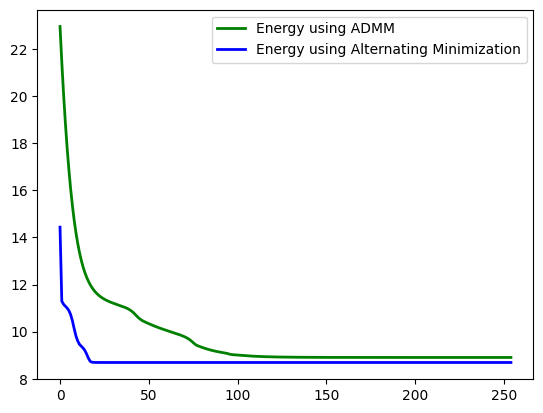

In [30]:
plt.close('all')
fig, ax = plt.subplots()
ax.plot(E_admm, linewidth = 2, color = 'Green', label = r'Energy using ADMM')
ax.plot(E_am, linewidth = 2, color = 'Blue', label = r'Energy using Alternating Minimization')

ax.legend()
plt.show()
